# Define the Business Problem
# Objective

# Analyze mobile-money transactions to identify:

Business Problem Statement

Analyze PaySim mobile-money transaction data to identify behavioral, transactional, and balance-related patterns associated with fraudulent transactions and provide actionable recommendations for improving fraud monitoring and risk detection.

# DATA UNDERSTANDING

Purpose:

Understand what the dataset contains.

This notebook ends before you start changing or deeply analyzing the data.

Include:

1. Import libraries

2. Load dataset

3. Dataset shape

4. Column names

5. Data types

6. First 5/10 rows

7. Last 5 rows

8. Statistical summary

9. Categorical summary

10. Unique values

11. Basic value counts

12. Identify numerical columns

13. Identify categorical columns

14. Identify identifier columns

15. Identify target variable

16. Explain every column

17. Define business problem

18. Define analytical objectives

## Load the Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

Why this Libraries
| Library      | Purpose                    |
| ------------ | -------------------------- |
| Pandas       | Data manipulation          |
| NumPy        | Numerical operations       |
| Matplotlib   | Visualization              |
| Seaborn      | Statistical visualization  |
| SciPy        | Statistical testing        |
| Scikit-learn | Optional ML and evaluation |


## Load the Dataset

In [2]:
import pandas as pd

# Load the Dataset
file_path = r"C:\Users\Asus\OneDrive\Desktop\Major_Project\Pay_Sim.csv"
df = pd.read_csv(file_path)


## Display the rows and columns

In [3]:
# Display the first few rows and shape to verify it loaded correctly
print(f"Original shape: {df.shape}")
df.head()

Original shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
# Understanding of Datatypes
df.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [5]:
# defining columns
df.columns.tolist()

['step',
 'type',
 'amount',
 'nameOrig',
 'oldbalanceOrg',
 'newbalanceOrig',
 'nameDest',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'isFlaggedFraud']

# Data Validation

## Clean and Check Names

In [6]:
# Strip any leading/trailing whitespace from string columns
for col in ['type', 'nameOrig', 'nameDest']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# PaySim specific check: 
# 'nameOrig' should always start with 'C' (Customer)
# 'nameDest' can start with 'C' (Customer) or 'M' (Merchant)
print("Unique prefixes in nameOrig:", df['nameOrig'].str[0].unique())
print("Unique prefixes in nameDest:", df['nameDest'].str[0].unique())

# Check for any unexpected formats in origin names
invalid_orig = df[~df['nameOrig'].str.startswith('C')].shape[0]
print(f"Number of invalid origin names: {invalid_orig}")

Unique prefixes in nameOrig: ['C']
Unique prefixes in nameDest: ['M' 'C']
Number of invalid origin names: 0


In [7]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

# Duplicates

## Check and Remove the Duplicates

In [8]:
initial_rows = len(df)
df = df.drop_duplicates()
print(f"Removed {initial_rows - len(df)} duplicate rows.")
print(f"Current shape after removing duplicates: {df.shape}")

Removed 0 duplicate rows.
Current shape after removing duplicates: (6362620, 11)


# Add Column

## Columns : errorbalanceOrg

## Columns : errorBalanceDest

## Columns : isMerchantaDest

## Columns : amount_to_org_balance

In [9]:
# A. Origin Balance Error: Discrepancy between old balance, amount, and new balance
df['errorBalanceOrg'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']

# B. Destination Balance Error: Discrepancy in destination account
df['errorBalanceDest'] = df['newbalanceDest'] + df['amount'] - df['oldbalanceDest']

# C. Merchant Destination Flag (1 if merchant 'M', 0 if customer 'C')
df['isMerchantDest'] = df['nameDest'].str.startswith('M').astype(int)

# D. Transaction to Balance Ratio (Proportion of origin balance being transferred)
df['amount_to_org_balance'] = df['amount'] / (df['oldbalanceOrg'] + 1e-5)

print(f"Processed shape with new feature columns: {df.shape}")
df.head(3)

Processed shape with new feature columns: (6362620, 15)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceOrg,errorBalanceDest,isMerchantDest,amount_to_org_balance
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0.0,9839.64,1,0.057834
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0.0,1864.28,1,0.087735
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,0.0,181.00,0,1.000000


# Data Quality

## Check nulls

In [10]:
# Check for missing values across all columns
missing_values = df.isnull().sum()
missing_values

step                     0
type                     0
amount                   0
nameOrig                 0
oldbalanceOrg            0
newbalanceOrig           0
nameDest                 0
oldbalanceDest           0
newbalanceDest           0
isFraud                  0
isFlaggedFraud           0
errorBalanceOrg          0
errorBalanceDest         0
isMerchantDest           0
amount_to_org_balance    0
dtype: int64

## Check missing and handled them

In [11]:
# Check for missing values across all columns
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values[missing_values > 0])

# If there are any missing values, you can fill or drop them:
# df = df.dropna()  # Uncomment if you want to drop rows with missing values

Missing values per column:
 Series([], dtype: int64)


## Unique Values/ Frequency Distribution

In [12]:
df["type"].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

In [13]:
df["type"].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

In [14]:
df["isFraud"].unique()

array([0, 1])

In [15]:
df["isMerchantDest"].unique()

array([1, 0])

In [16]:
#Transaction types:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [17]:
# Fraud
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [18]:
# Flagged Fraud
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [19]:
# Ṃerchant Destination
df["isMerchantDest"].value_counts()

isMerchantDest
0    4211125
1    2151495
Name: count, dtype: int64

Understand the composition of the dataset before analysis.

# Statistical Summary

In [20]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceOrg,errorBalanceDest,isMerchantDest,amount_to_org_balance
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06,-2.010925e+05,3.041566e+05,3.381461e-01,7.060226e+09
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03,6.066505e+05,1.362381e+06,4.730786e-01,5.084300e+10
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-9.244552e+07,-1.293042e+07,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.496411e+05,3.815940e+03,0.000000e+00,2.344134e-01
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00,-6.867726e+04,2.774842e+04,0.000000e+00,6.458505e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00,-2.954230e+03,3.083917e+05,1.000000e+00,1.213350e+09
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00,1.000000e-02,1.848910e+08,1.000000e+00,9.244552e+12


## Categorical Columns

In [21]:
# For categorical columns
df.describe(include="object")

,type,nameOrig,nameDest
count,6362620,6362620,6362620
unique,5,6353307,2722362
top,CASH_OUT,C1902386530,C1286084959
freq,2237500,3,113


## Validate Financial column

In [22]:
financial_columns = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

(df[financial_columns] < 0).sum()

amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
dtype: int64

## Validate Fraud Columns

In [23]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [24]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [25]:
df["isFraud"].unique()

array([0, 1])

In [26]:
df["isFlaggedFraud"].unique()

array([0, 1])

# EXISTING FEATURE VALIDATION

In [27]:
# I have already created four useful analytical features:

In [28]:
# errorBalanceOrg
# errorBalanceDest
# isMerchantDest
# amount_to_org_balance
# We Now Validate them

## Validate errorBalanceOrg

In [29]:
calculated_error = (
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"]
)

(df["errorBalanceOrg"] - calculated_error).abs().max()
# Concept used
# oldbalanceOrg - amount - newbalanceOrig

0.0

## Validate errorBalanceDest

In [30]:
calculated_error = (
    df["oldbalanceDest"]
    + df["amount"]
    - df["newbalanceDest"]
)

(df["errorBalanceDest"] - calculated_error).abs().max()
# Concept use
# oldbalanceDest + amount - newbalanceDest

211375677.64

## Validate amount_to_org_balance

This represents:

Transaction amount relative to the sender's original balance.

Check your existing calculation.

For non-zero balances:

In [31]:
calculated_ratio = np.where(
    df["oldbalanceOrg"] > 0,
    df["amount"] / df["oldbalanceOrg"],
    0
)

In [32]:
# Compare
np.max(
    np.abs(
        df["amount_to_org_balance"] - calculated_ratio
    )
)

9244551664000.0

## Validate isMerchantDest

In [33]:
df.groupby("isMerchantDest")["nameDest"].nunique()

isMerchantDest
0     571961
1    2150401
Name: nameDest, dtype: int64

In [34]:
pd.crosstab(
    df["isMerchantDest"],
    df["isFraud"]
)

isFraud,0,1
isMerchantDest,,
0,4202912,8213
1,2151495,0


# Fraud Check

## TARGET VARIABLE ANALYSI

### Analyze Fraud Distribution

In [35]:
fraud_counts = df["isFraud"].value_counts()

fraud_counts

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [36]:
# Business purpose

# Determine whether the dataset is imbalanced.

# In fraud detection, this is critical because fraud normally represents a small fraction of total transactions.

In [37]:
fraud_percentage = (
    df["isFraud"]
    .value_counts(normalize=True)
    * 100
)

fraud_percentage

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

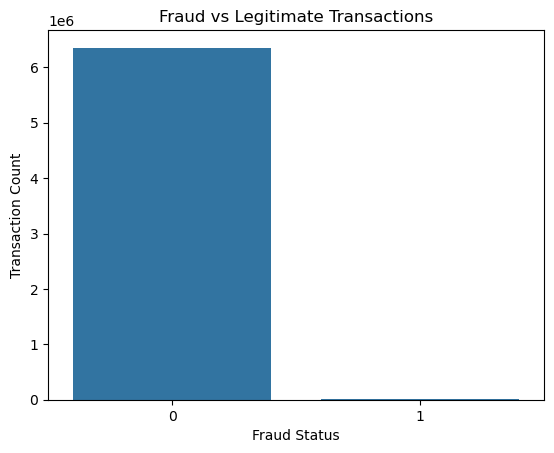

In [38]:
sns.countplot(data=df, x="isFraud")

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Fraud Status")
plt.ylabel("Transaction Count")

plt.show()

In [39]:
fraud_rate = df["isFraud"].mean() * 100

fraud_rate

np.float64(0.12908204481801522)

Document:

The overall fraud rate is X%.

This becomes an important KPI for Power BI

# UNIVARIATE EDA

## Transaction Type Analysis

In [40]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

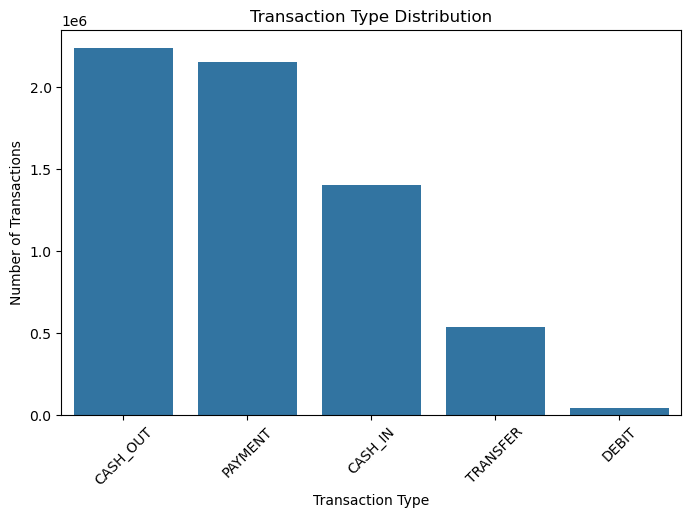

In [41]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="type",
    order=df["type"].value_counts().index
)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

In [42]:
# Questions
# Which transaction type is most common?
# Which is least common?
# Does the dataset have transaction-type imbalance?

## Transaction Amount Distribution

In [43]:
df["amount"].describe()

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

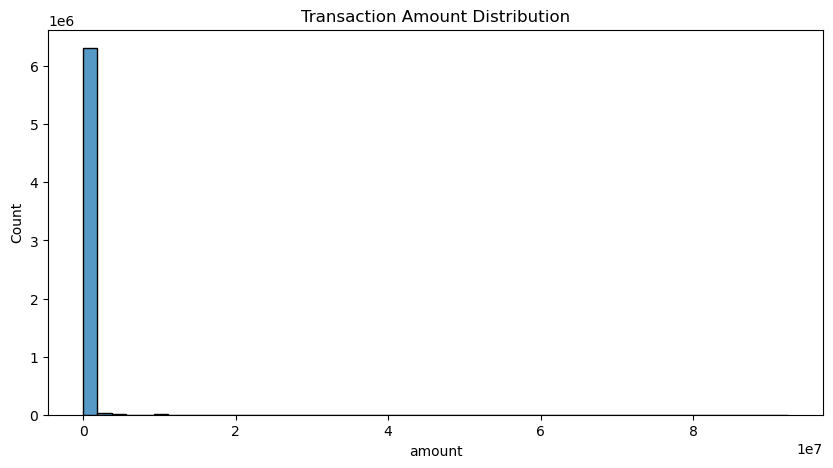

In [44]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="amount",
    bins=50
)

plt.title("Transaction Amount Distribution")

plt.show()

Because financial data is usually highly skewed, also try:

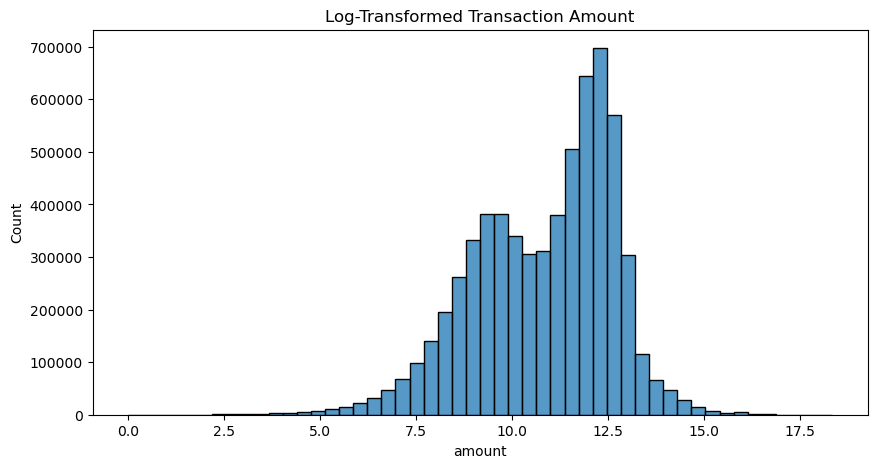

In [45]:
plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(df["amount"]),
    bins=50
)

plt.title("Log-Transformed Transaction Amount")

plt.show()

## Sender Balance Analysis

In [46]:
df["oldbalanceOrg"].describe()

count    6.362620e+06
mean     8.338831e+05
std      2.888243e+06
min      0.000000e+00
25%      0.000000e+00
50%      1.420800e+04
75%      1.073152e+05
max      5.958504e+07
Name: oldbalanceOrg, dtype: float64

In [47]:
df["newbalanceOrig"].describe()

count    6.362620e+06
mean     8.551137e+05
std      2.924049e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.442584e+05
max      4.958504e+07
Name: newbalanceOrig, dtype: float64

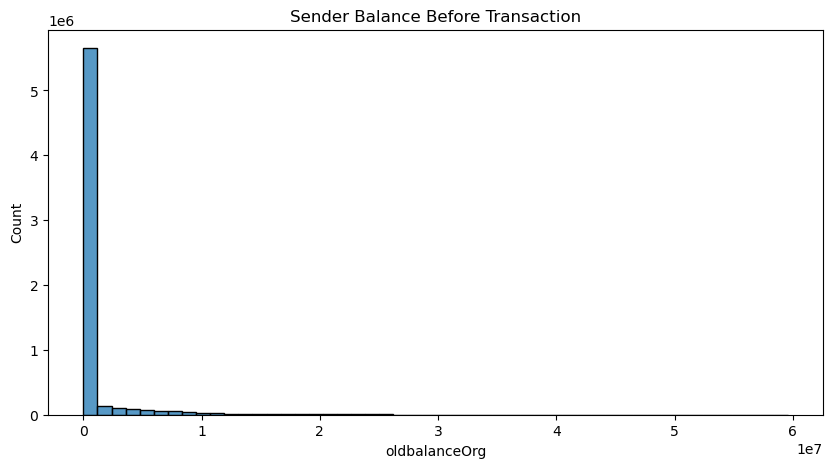

In [48]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["oldbalanceOrg"],
    bins=50
)

plt.title("Sender Balance Before Transaction")

plt.show()

## Destination Balance Analysis

In [49]:
df["oldbalanceDest"].describe()

count    6.362620e+06
mean     1.100702e+06
std      3.399180e+06
min      0.000000e+00
25%      0.000000e+00
50%      1.327057e+05
75%      9.430367e+05
max      3.560159e+08
Name: oldbalanceDest, dtype: float64

In [50]:
df["newbalanceDest"].describe()

count    6.362620e+06
mean     1.224996e+06
std      3.674129e+06
min      0.000000e+00
25%      0.000000e+00
50%      2.146614e+05
75%      1.111909e+06
max      3.561793e+08
Name: newbalanceDest, dtype: float64

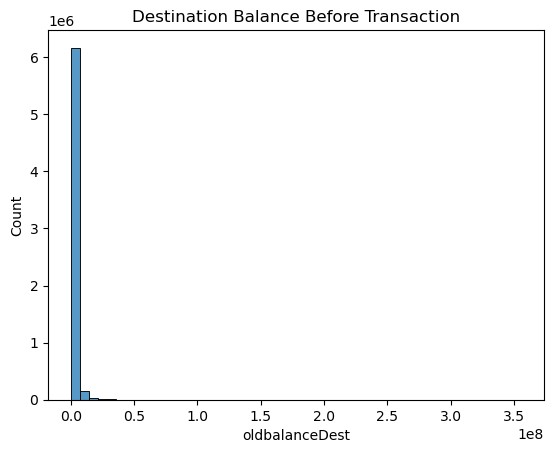

In [51]:
sns.histplot(
    df["oldbalanceDest"],
    bins=50
)

plt.title("Destination Balance Before Transaction")

plt.show()

## BIVARIATE FRAUD ANALYSIS

### Fraud by Transaction Type

In [52]:
fraud_by_type = (
    df.groupby("type")["isFraud"]
    .agg(
        total_transactions="count",
        fraud_transactions="sum",
        fraud_rate="mean"
    )
    .sort_values(
        "fraud_rate",
        ascending=False
    )
)

fraud_by_type

,total_transactions,fraud_transactions,fraud_rate
type,,,
TRANSFER,532909,4097,0.007688
CASH_OUT,2237500,4116,0.001840
CASH_IN,1399284,0,0.000000
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000


In [53]:
# Convert into percentage
fraud_by_type["fraud_rate"] *= 100

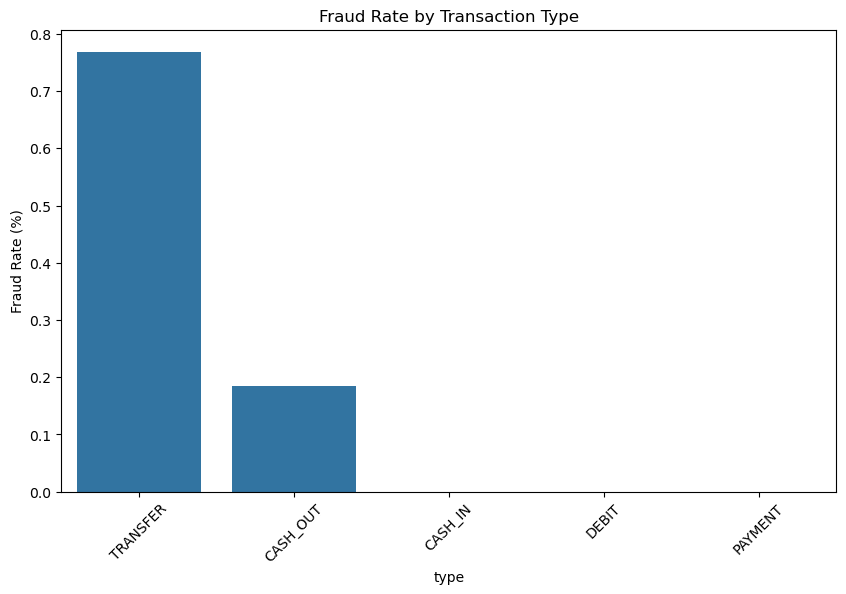

In [54]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=fraud_by_type.reset_index(),
    x="type",
    y="fraud_rate"
)

plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=45)

plt.show()

## Fraud vs Transaction Amount

In [55]:
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


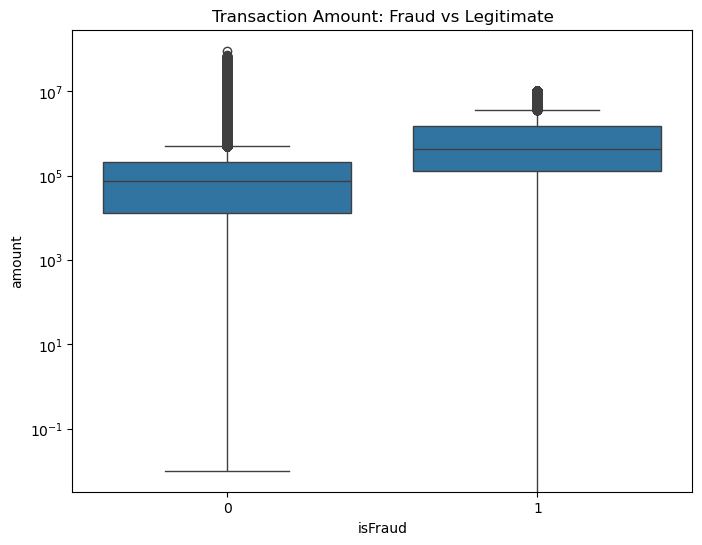

In [56]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="isFraud",
    y="amount"
)

plt.yscale("log")

plt.title("Transaction Amount: Fraud vs Legitimate")

plt.show()

Do fraudulent transactions have different transaction amounts compared with legitimate transactions?

### Fraud by Time

In [57]:
df["hour"] = df["step"] % 24

In [58]:
fraud_by_hour = (
    df.groupby("hour")["isFraud"]
    .mean()
    * 100
)

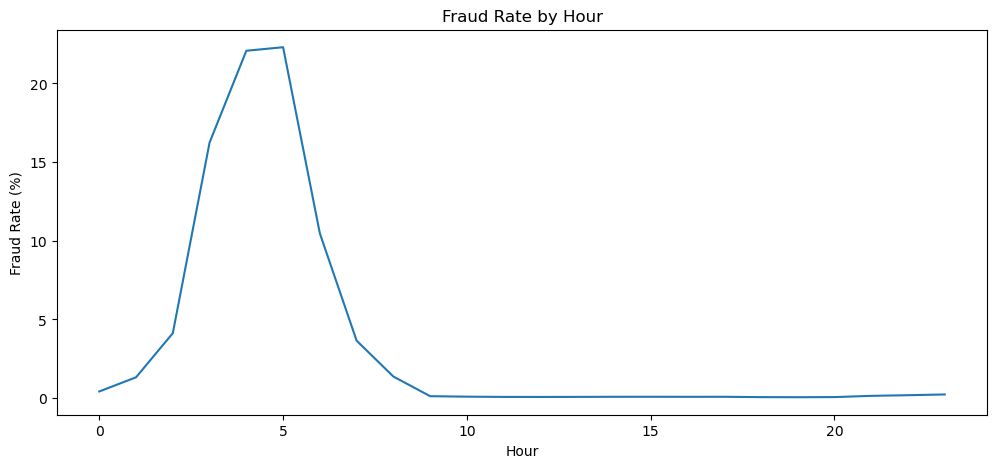

In [59]:
plt.figure(figsize=(12,5))

fraud_by_hour.plot()

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")

plt.show()

Are fraudulent transactions concentrated during particular time periods?

### Fraud by Day

In [60]:
df["day"] = df["step"] // 24

In [61]:
fraud_by_day = (
    df.groupby("day")["isFraud"]
    .mean()
    * 100
)

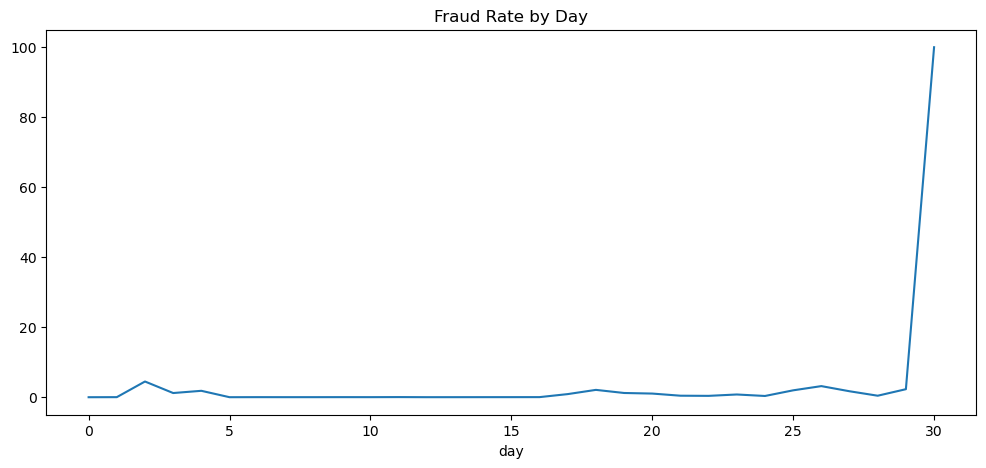

In [62]:
plt.figure(figsize=(12,5))

fraud_by_day.plot()

plt.title("Fraud Rate by Day")

plt.show()

## Fraud vs Sender Balance

In [63]:
df.groupby("isFraud")["oldbalanceOrg"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,8.328287e+05,2.887144e+06,0.0,0.00,14069.00,106969.50,43818855.30
1,8213.0,1.649668e+06,3.547719e+06,0.0,125822.44,438983.45,1517771.48,59585040.37


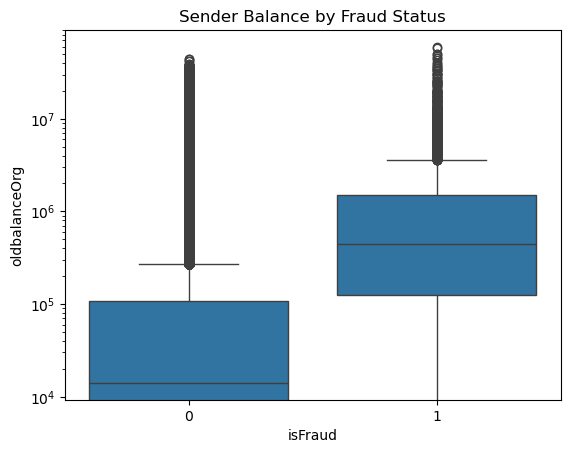

In [64]:
sns.boxplot(
    data=df,
    x="isFraud",
    y="oldbalanceOrg"
)

plt.yscale("log")

plt.title("Sender Balance by Fraud Status")

plt.show()

## Fraud vs Balance Errors

In [65]:
df.groupby("isFraud")[
    ["errorBalanceOrg", "errorBalanceDest"]
].mean()

,errorBalanceOrg,errorBalanceDest
isFraud,,
0,-201338.558109,3.017019e+05
1,-10692.325265,2.203425e+06


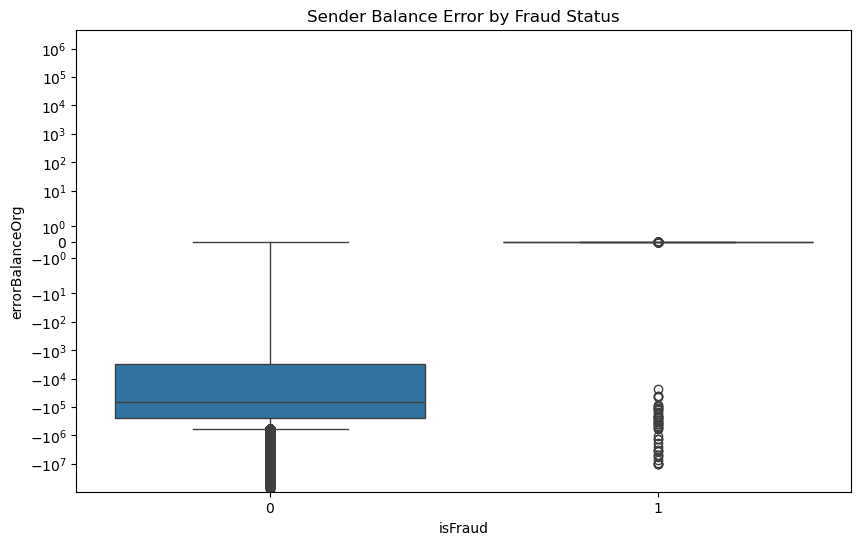

In [66]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="isFraud",
    y="errorBalanceOrg"
)

plt.yscale("symlog")

plt.title("Sender Balance Error by Fraud Status")

plt.show()

Are fraudulent transactions more likely to have unusual balance inconsistencies?

## Fraud vs Amount-to-Balance Ratio

In [67]:
df.groupby("isFraud")[
    "amount_to_org_balance"
].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,7.069202e+09,5.087510e+10,1.765481e-08,0.233414,6.516319,1.220032e+09,9.244552e+12
1,8213.0,1.160973e+08,3.229719e+09,0.000000e+00,1.000000,1.000000,1.000000e+00,1.933921e+11


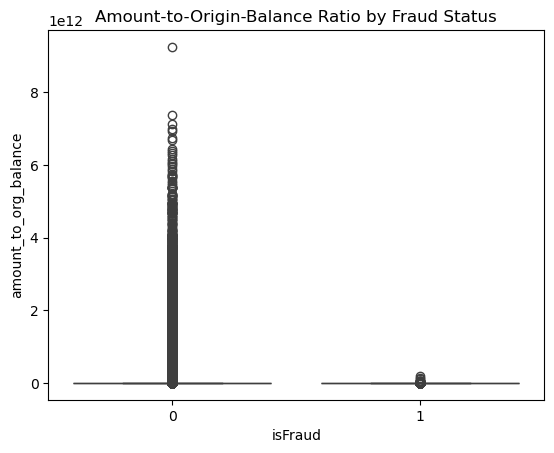

In [68]:
sns.boxplot(
    data=df,
    x="isFraud",
    y="amount_to_org_balance"
)

plt.title("Amount-to-Origin-Balance Ratio by Fraud Status")

plt.show()

# FRAUD + FLAGGING SYSTEM

## Analyze isFlaggedFraud

In [69]:
flagged_analysis = pd.crosstab(
    df["isFraud"],
    df["isFlaggedFraud"]
)

flagged_analysis

isFlaggedFraud,0,1
isFraud,,
0,6354407,0
1,8197,16


In [70]:
pd.crosstab(
    df["isFlaggedFraud"],
    df["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
isFlaggedFraud,,
0,99.871169,0.128831
1,0.000000,100.000000


Among transactions flagged by the existing system, what percentage were actually fraudulent?

# Confusion Matrix

In [71]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    df["isFraud"],
    df["isFlaggedFraud"]
)

cm

array([[6354407,       0],
       [   8197,      16]])

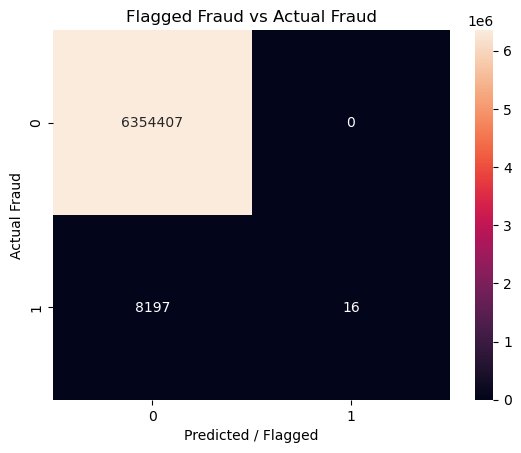

In [72]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted / Flagged")
plt.ylabel("Actual Fraud")

plt.title("Flagged Fraud vs Actual Fraud")

plt.show()

In [73]:
precision = precision_score(
    df["isFraud"],
    df["isFlaggedFraud"],
    zero_division=0
)

recall = recall_score(
    df["isFraud"],
    df["isFlaggedFraud"],
    zero_division=0
)

f1 = f1_score(
    df["isFraud"],
    df["isFlaggedFraud"],
    zero_division=0
)

precision, recall, f1

(1.0, 0.0019481310118105442, 0.0038886863531413293)

How effective is the existing fraud-flagging mechanism?

# ACCOUNT ANALYSIS

## Identify Fraudulent Senders

In [74]:
fraud_senders = (
    df[df["isFraud"] == 1]
    .groupby("nameOrig")
    .agg(
        fraud_transactions=("isFraud", "sum"),
        total_amount=("amount", "sum")
    )
    .sort_values(
        "fraud_transactions",
        ascending=False
    )
)

fraud_senders.head(20)

,fraud_transactions,total_amount
nameOrig,,
C1000036340,1,253648.68
C334503836,1,964876.58
C357089378,1,801763.51
C356905617,1,6646879.72
C356781229,1,1715635.41
C356706674,1,19421.77
C356571967,1,122235.11
C356480504,1,8838.19
C356205172,1,48712.12


## Identify Fraudulent Destinations

In [75]:
fraud_destinations = (
    df[df["isFraud"] == 1]
    .groupby("nameDest")
    .agg(
        fraud_transactions=("isFraud", "sum"),
        total_amount=("amount", "sum")
    )
    .sort_values(
        "fraud_transactions",
        ascending=False
    )
)

fraud_destinations.head(20)

,fraud_transactions,total_amount
nameDest,,
C2020337583,2,579140.87
C650699445,2,408028.65
C475338087,2,730733.52
C505532836,2,174238.21
C1185292292,2,225576.15
C1399829166,2,3540009.28
C643624257,2,3071716.97
C967226405,2,1416085.46
C1366192319,2,7061799.65


Identify accounts repeatedly appearing in fraudulent transactions.

# ADVANCED FEATURE ENGINEERING

## Create Time Categories

In [76]:
def time_period(hour):
    if 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 18:
        return "Afternoon"
    elif 18 <= hour < 24:
        return "Evening"
    else:
        return "Night"

df["time_period"] = df["hour"].apply(time_period)

In [77]:
df.groupby("time_period")["isFraud"].mean() * 100

time_period
Afternoon    0.077218
Evening      0.086487
Morning      0.175294
Night        1.772568
Name: isFraud, dtype: float64

## Create Large Transaction Flag

In [78]:
threshold = df["amount"].quantile(0.95)

df["large_transaction"] = (
    df["amount"] >= threshold
).astype(int)

In [79]:
df.groupby("large_transaction")["isFraud"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
large_transaction,,,
0,6044489,4410,0.000730
1,318131,3803,0.011954


Are transactions in the top 5% by amount more likely to be fraudulent?

## Create Balance Utilization Category

In [80]:
df["balance_utilization"] = pd.cut(
    df["amount_to_org_balance"],
    bins=[
        -np.inf,
        0.25,
        0.50,
        0.75,
        1.00,
        np.inf
    ],
    labels=[
        "<25%",
        "25-50%",
        "50-75%",
        "75-100%",
        ">100%"
    ]
)

In [81]:
df.groupby(
    "balance_utilization",
    observed=True
)["isFraud"].mean() * 100

balance_utilization
<25%       0.001667
25-50%     0.013038
50-75%     0.025286
75-100%    5.468475
>100%      0.000711
Name: isFraud, dtype: float64

# MULTIVARIATE ANALYSIS

## Correlation and Relationship Analysis

In [82]:
numeric_columns = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
    "isFlaggedFraud",
    "errorBalanceOrg",
    "errorBalanceDest",
    "isMerchantDest",
    "amount_to_org_balance"
]

corr = df[numeric_columns].corr()

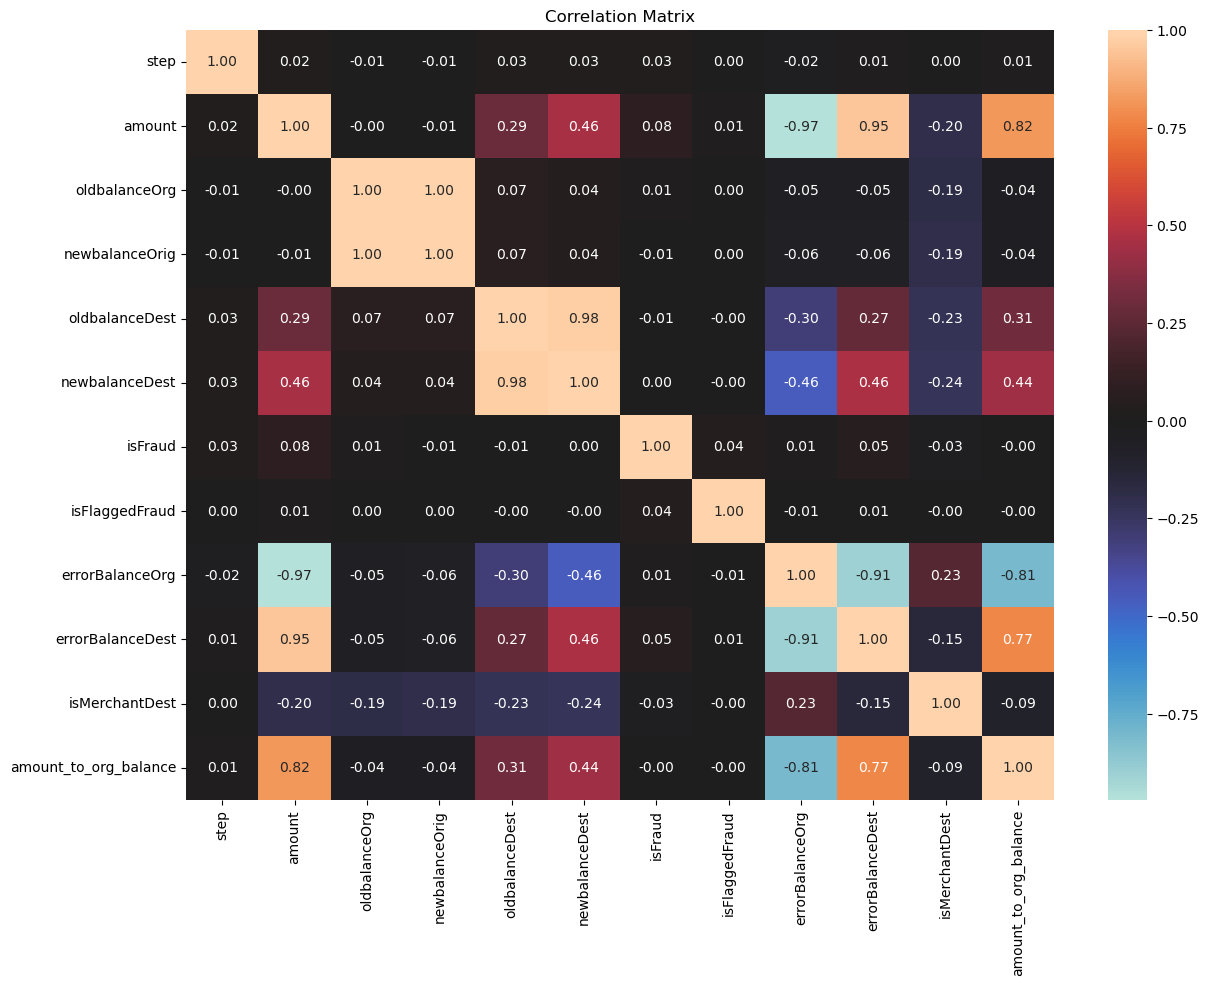

In [83]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

Correlation does not prove causation.

Use it to identify relationships worth investigating

# STATISTICAL ANALYSIS

## Statistical Testing

This makes your project more analytical.

For example, compare transaction amounts between fraudulent and legitimate transactions.

Because transaction amounts are likely highly skewed, a Mann–Whitney U test is often more appropriate than assuming normality.

In [84]:
fraud_amount = df.loc[
    df["isFraud"] == 1,
    "amount"
]

legit_amount = df.loc[
    df["isFraud"] == 0,
    "amount"
]

In [85]:
stat, p_value = stats.mannwhitneyu(
    fraud_amount,
    legit_amount,
    alternative="two-sided"
)

stat, p_value

(np.float64(41224999611.0), np.float64(0.0))

# Final Step

Save the final DataFrame after profiling/feature engineering

In [88]:
# Check final columns
print("Final Columns:")
print(df.columns.tolist())

# Check final shape
print("\nFinal Shape:", df.shape)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

Final Columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'errorBalanceOrg', 'errorBalanceDest', 'isMerchantDest', 'amount_to_org_balance', 'hour', 'day', 'time_period', 'large_transaction', 'balance_utilization']

Final Shape: (6362620, 20)

Missing Values:
step                     0
type                     0
amount                   0
nameOrig                 0
oldbalanceOrg            0
newbalanceOrig           0
nameDest                 0
oldbalanceDest           0
newbalanceDest           0
isFraud                  0
isFlaggedFraud           0
errorBalanceOrg          0
errorBalanceDest         0
isMerchantDest           0
amount_to_org_balance    0
hour                     0
day                      0
time_period              0
large_transaction        0
balance_utilization      0
dtype: int64

Duplicate Rows: 0


In [89]:
# Save final dataset
df.to_csv("paysim_final.csv", index=False)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [90]:
df.to_csv("paysim_final.csv", index=False)